#Langues turciques

Decoder Only Plus Ollama

In [3]:
import pandas as pd
from sentence_transformers import SentenceTransformer

# Read the CSV file
df = pd.read_csv('turcique.csv')


df['turcique_text'] = df['original_text']
df['english_text'] = df['text']

In [6]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from sentence_transformers import SentenceTransformer

# Initialize SentenceTransformer model with a multilingual model
model_st = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Generate English embeddings
print("Generating English embeddings...")
english_embeddings = model_st.encode(df['english_text'].tolist(), show_progress_bar=True)

# Generate Turcique embeddings
print("Generating Turcique embeddings...")
turcique_embeddings = model_st.encode(df['turcique_text'].tolist(), show_progress_bar=True)

# Create separate DataFrames with embeddings
english_df = pd.DataFrame({
    'text': df['english_text'],
    'language': 'English',
    'embedding': list(english_embeddings)
})

turcique_df = pd.DataFrame({
    'text': df['turcique_text'],
    'language': 'Turcique',
    'embedding': list(turcique_embeddings)
})

# Combine both DataFrames
combined_df = pd.concat([english_df, turcique_df], ignore_index=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generating English embeddings...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Generating Turcique embeddings...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [12]:
# Reduce embeddings to 2D using UMAP
from umap import UMAP
import numpy as np
# Reduce embeddings to 2D using UMAP
print("Reducing embeddings to 2D...")
all_embeddings = np.vstack(combined_df['embedding'].values)
reducer = UMAP(n_components=2, random_state=42)
embeddings_2d = reducer.fit_transform(all_embeddings)

# Add 2D coordinates to dataframe
combined_df['x'] = embeddings_2d[:, 0]
combined_df['y'] = embeddings_2d[:, 1]

# Save to CSV for online visualization
output_df = combined_df[['text', 'language', 'x', 'y']].copy()
output_df.to_csv('embeddings_2d.csv', index=False)
print("Saved embeddings to 'embeddings_2d.csv'")

# Also save with full embeddings in parquet format
combined_df.to_parquet('embeddings_full.parquet')
print("Saved full embeddings to 'embeddings_full.parquet'")

print(f"\nDataset info: {len(output_df)} points total")
print(f"English: {len(output_df[output_df['language']=='English'])} points")
print(f"Turcique: {len(output_df[output_df['language']=='Turcique'])} points")

Reducing embeddings to 2D...
Saved embeddings to 'embeddings_2d.csv'
Saved full embeddings to 'embeddings_full.parquet'

Dataset info: 58 points total
English: 29 points
Turcique: 29 points


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [13]:
# Calculate distances between English and Turkish points
english_points = embeddings_2d[:len(english_embeddings)]
turcique_points = embeddings_2d[len(turcique_embeddings):]

distances = []
for i in range(len(english_points)):
    dist = np.sqrt((english_points[i][0] - turcique_points[i][0])**2 +
                   (english_points[i][1] - turcique_points[i][1])**2)
    distances.append(dist)

avg_distance = np.mean(distances)

print(f"\nAverage distance between English and Turkish: {avg_distance:.4f}")
print(f"Min distance: {np.min(distances):.4f}")
print(f"Max distance: {np.max(distances):.4f}")


Average distance between English and Turkish: 1.2720
Min distance: 0.0893
Max distance: 3.8207


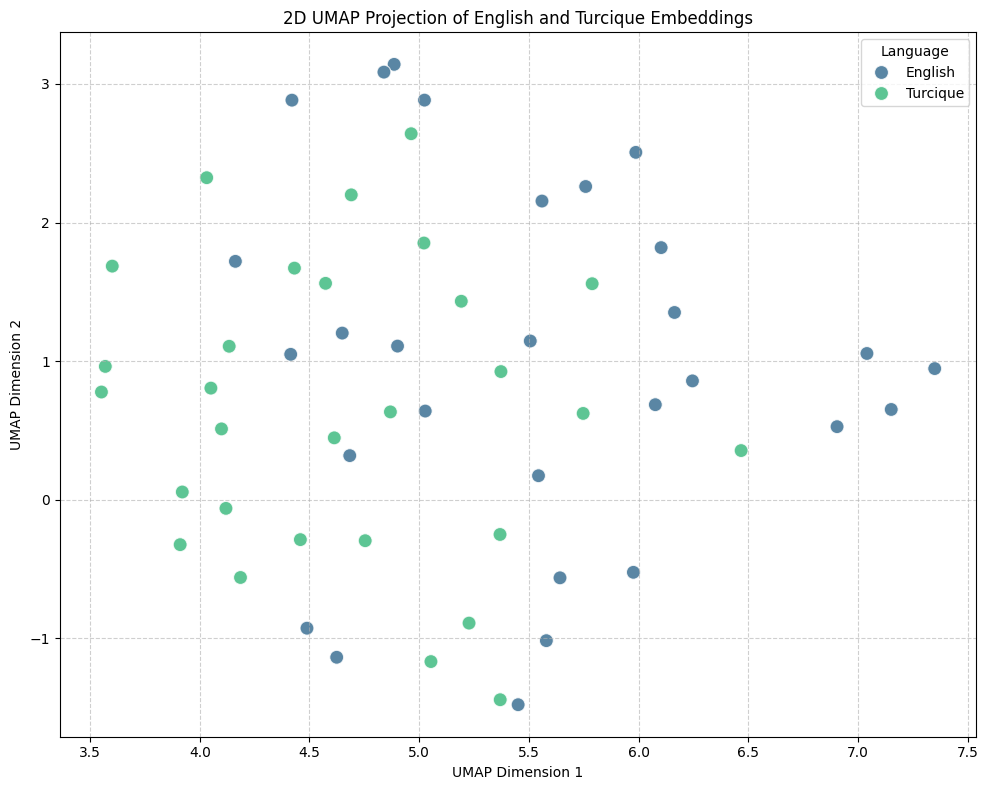

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='x', y='y', hue='language', data=combined_df, palette='viridis', s=100, alpha=0.8)

# Add title and labels
plt.title('2D UMAP Projection of English and Turcique Embeddings')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(title='Language')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In Terminal : embedding-atlas Code2Qwen/embeddings_full.parquet --x x --y y --text text